# ClarityNet: Baseline CNN Training

This notebook:
1. Loads the train/val/test splits from notebook 02
2. Defines the U-Net CNN baseline architecture
3. Implements the training loop with validation on seen and unseen noise
4. Tracks the generalization gap during training
5. Saves checkpoints and training history

**Prerequisites:** Run notebook 02 first to ensure data is ready.

In [1]:
# Imports
import os
import sys
import json
import random
import numpy as np
# %matplotlib inline

from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

# For module imports
PROJECT_ROOT = Path("../").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.dataset import WaveformDataset
from src.data.manifest import load_manifest
from src.evaluation.metrics import validate_with_metrics

# Set seeds for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

print("Imports successful!")

✓ Dataset class defined
Imports successful!


In [2]:
print(f"PyTorch  : {torch.__version__}")
print(f"CUDA     : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU      : {torch.cuda.get_device_name(0)}")

PyTorch  : 2.10.0+cu128
CUDA     : True
GPU      : NVIDIA GeForce RTX 2080 SUPER


## Configuration

In [3]:
# Training hyperparameters
BATCH_SIZE = 8
LEARNING_RATE = 1e-3
NUM_EPOCHS = 50
PATIENCE = 10  # Early stopping patience
SAVE_EVERY = 5  # Save checkpoint every N epochs

# Paths
PROJECT_ROOT = Path("..").resolve() 
MANIFEST_PATH = PROJECT_ROOT / "data/MANIFEST.json"
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints/baseline_cnn"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR = PROJECT_ROOT / "results/baseline_cnn"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Device
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

print(f"Configuration:")
print(f"  Device: {DEVICE}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Epochs: {NUM_EPOCHS}")
print(f"  Checkpoint dir: {CHECKPOINT_DIR}")
print(f"  Results dir: {RESULTS_DIR}")

Configuration:
  Device: cuda
  Batch size: 8
  Learning rate: 0.001
  Epochs: 50
  Checkpoint dir: /home/paul/Desktop/projects/clarity-net/checkpoints/baseline_cnn
  Results dir: /home/paul/Desktop/projects/clarity-net/results/baseline_cnn


## Dataset Class (from Notebook 02)

In [4]:
print("Creating datasets...\n")

splits = load_manifest(MANIFEST_PATH)

train_dataset = WaveformDataset(
    clean_files=splits['train'], 
    noise_files=splits['noise_seen'], 
    mode='train',
    augmentation_factor=5,
    base_seed=42,
    epoch=0
)

val_seen_dataset = WaveformDataset(
    clean_files=splits['val'],
    noise_files=splits['noise_seen'],
    mode='val')

val_unseen_dataset = WaveformDataset(
    clean_files=splits['val'],
    noise_files=splits['noise_unseen'],
    mode='val')

test_seen_dataset = WaveformDataset(
    clean_files=splits['test'],
    noise_files=splits['noise_seen'],
    mode='test')

test_unseen_dataset = WaveformDataset(
    clean_files=splits['test'],
    noise_files=splits['noise_unseen'],
    mode='test')

print("\n" + "="*60)
print(f"Training:          {len(train_dataset)} pairs")
print(f"Validation (seen): {len(val_seen_dataset)} pairs")
print(f"Validation (uns.): {len(val_unseen_dataset)} pairs")
print(f"Test (seen):       {len(test_seen_dataset)} pairs")
print(f"Test (uns.):       {len(test_unseen_dataset)} pairs")
print("="*60)

Creating datasets...

[TRAIN] Loading 140 clean files...
[TRAIN] Loading 23 noise files...
[TRAIN] 255 clean, 46 noise segments
[VAL] Loading 30 clean files...
[VAL] Loading 23 noise files...
[VAL] 51 clean, 46 noise segments
[VAL] Loading 30 clean files...
[VAL] Loading 30 noise files...
[VAL] 51 clean, 60 noise segments
[TEST] Loading 30 clean files...
[TEST] Loading 23 noise files...
[TEST] 48 clean, 46 noise segments
[TEST] Loading 30 clean files...
[TEST] Loading 30 noise files...
[TEST] 48 clean, 60 noise segments

Training:          1275 pairs
Validation (seen): 51 pairs
Validation (uns.): 51 pairs
Test (seen):       48 pairs
Test (uns.):       48 pairs


## Create Datasets

In [5]:
# print("Creating datasets...\n")

# MANIFEST_PATH = PROJECT_ROOT / "data/MANIFEST.json"

# train_dataset = CNNDataset(MANIFEST_PATH, "train", root_dir=PROJECT_ROOT)
# val_seen_dataset = CNNDataset(MANIFEST_PATH, "val_seen", root_dir=PROJECT_ROOT)
# val_unseen_dataset = CNNDataset(MANIFEST_PATH, "val_unseen", root_dir=PROJECT_ROOT)
# test_seen_dataset = CNNDataset(MANIFEST_PATH, "test_seen", root_dir=PROJECT_ROOT)
# test_unseen_dataset = CNNDataset(MANIFEST_PATH, "test_unseen", root_dir=PROJECT_ROOT)

# print("\n" + "="*60)
# print(f"Training:          {len(train_dataset)} pairs")
# print(f"Validation (seen): {len(val_seen_dataset)} pairs")
# print(f"Validation (uns.): {len(val_unseen_dataset)} pairs")
# print(f"Test (seen):       {len(test_seen_dataset)} pairs")
# print(f"Test (uns.):       {len(test_unseen_dataset)} pairs")
# print("="*60)

## Create DataLoaders

In [6]:
# Ensure shuffling is deterministic for reproducibility
train_gen = torch.Generator().manual_seed(42)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, generator=train_gen)
val_seen_loader = DataLoader(val_seen_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
val_unseen_loader = DataLoader(val_unseen_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_seen_loader = DataLoader(test_seen_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_unseen_loader = DataLoader(test_unseen_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"DataLoaders created:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val (seen) batches: {len(val_seen_loader)}")
print(f"  Val (unseen) batches: {len(val_unseen_loader)}")
print(f"  Test (seen) batches: {len(test_seen_loader)}")
print(f"  Test (unseen) batches: {len(test_unseen_loader)}")

DataLoaders created:
  Train batches: 160
  Val (seen) batches: 7
  Val (unseen) batches: 7
  Test (seen) batches: 6
  Test (unseen) batches: 6


## Define U-Net CNN Model

In [7]:
from src.models.baseline_cnn import UNetCNN
from src.models.model_utils import count_parameters

# Create model
model = UNetCNN(in_channels=1, base_channels=32).to(DEVICE)
print(f"Model created with {count_parameters(model):,} parameters")
    
# Test multiple sizes to ensure it works
test_sizes = [
    (2, 1, 257, 501),  # Actual STFT size from data
    (2, 1, 257, 251),  # Alternative size
    (2, 1, 256, 500),  # Even dimensions
]
    
print("Model Architecture Test")
print(f"Total parameters: {count_parameters(model):,}\n")
    
for test_size in test_sizes:
    x = torch.randn(*test_size).to(DEVICE)
        
    with torch.no_grad():
         output = model(x).cpu()
        
    print(f"Input:  {tuple(x.shape)} -> Output: {tuple(output.shape)}")
    assert x.shape == output.shape, f"Size mismatch! {x.shape} != {output.shape}"
    
    print("\n✓ All tests passed! Output size matches input size exactly.")

# Test forward pass
test_batch = next(iter(train_loader))
with torch.no_grad():
    test_out = model(test_batch['noisy'].to(DEVICE))
print(f"Test forward pass: {test_batch['noisy'].shape} -> {test_out.shape}")
print("✓ Model ready")

Model created with 7,851,969 parameters
Model Architecture Test
Total parameters: 7,851,969

Input:  (2, 1, 257, 501) -> Output: (2, 1, 257, 501)

✓ All tests passed! Output size matches input size exactly.
Input:  (2, 1, 257, 251) -> Output: (2, 1, 257, 251)

✓ All tests passed! Output size matches input size exactly.
Input:  (2, 1, 256, 500) -> Output: (2, 1, 256, 500)

✓ All tests passed! Output size matches input size exactly.
Test forward pass: torch.Size([8, 1, 257, 501]) -> torch.Size([8, 1, 257, 501])
✓ Model ready


## Training Setup

In [8]:
# Loss and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Learning rate scheduler (optional)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

print(f"Loss function: MSE")
print(f"Optimizer: Adam (lr={LEARNING_RATE})")
print(f"Scheduler: ReduceLROnPlateau")

Loss function: MSE
Optimizer: Adam (lr=0.001)
Scheduler: ReduceLROnPlateau


Val seen SNR:
  count: 51
  mean:  9.19 dB
  std:   6.03 dB
  min:   0.64 dB
  q25:   4.11 dB
  q50:   7.91 dB
  q75:   14.66 dB
  max:   19.70 dB

Val unseen SNR:
  count: 51
  mean:  10.60 dB
  std:   6.04 dB
  min:   0.01 dB
  q25:   5.16 dB
  q50:   10.19 dB
  q75:   15.07 dB
  max:   19.95 dB



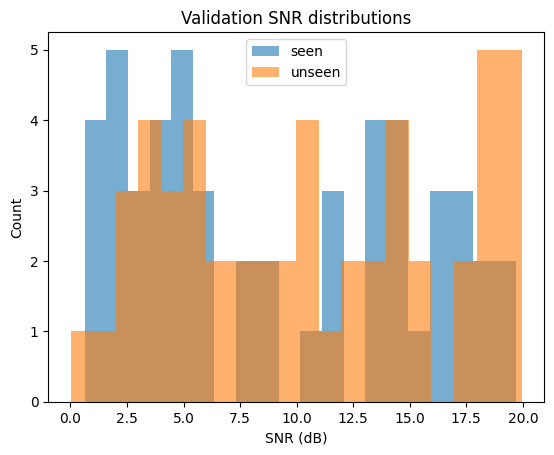

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def collect_snrs(loader):
    snrs = []
    for batch in loader:
        batch_snrs = batch["snr"]

        # handle tensor or plain list
        if hasattr(batch_snrs, "cpu"):
            snrs.extend(batch_snrs.cpu().numpy().tolist())
        else:
            snrs.extend(list(batch_snrs))

    return np.array(snrs, dtype=float)

def summarize_snrs(name, snrs):
    print(f"{name}:")
    print(f"  count: {len(snrs)}")
    print(f"  mean:  {snrs.mean():.2f} dB")
    print(f"  std:   {snrs.std():.2f} dB")
    print(f"  min:   {snrs.min():.2f} dB")
    print(f"  q25:   {np.percentile(snrs, 25):.2f} dB")
    print(f"  q50:   {np.percentile(snrs, 50):.2f} dB")
    print(f"  q75:   {np.percentile(snrs, 75):.2f} dB")
    print(f"  max:   {snrs.max():.2f} dB")
    print()

seen_snrs = collect_snrs(val_seen_loader)
unseen_snrs = collect_snrs(val_unseen_loader)

summarize_snrs("Val seen SNR", seen_snrs)
summarize_snrs("Val unseen SNR", unseen_snrs)

plt.hist(seen_snrs, bins=20, alpha=0.6, label="seen")
plt.hist(unseen_snrs, bins=20, alpha=0.6, label="unseen")
plt.xlabel("SNR (dB)")
plt.ylabel("Count")
plt.title("Validation SNR distributions")
plt.legend()
plt.show()

## Run Training

In [10]:
%%time

"""
Updated training loop with PESQ/STOI metrics.

Replace your current training loop with this version.
"""

from src.models.model_utils import save_checkpoint, train_epoch
from src.evaluation.metrics import validate_with_metrics

# Training history - EXPANDED to include PESQ/STOI
history = {
    'train_loss': [],
    'val_seen_loss': [],
    'val_seen_pesq': [],
    'val_seen_stoi': [],
    'val_unseen_loss': [],
    'val_unseen_pesq': [],
    'val_unseen_stoi': [],
    'generalization_gap_loss': [],
    'generalization_gap_pesq': [],
    'generalization_gap_stoi': [],
    'learning_rate': []
}

best_val_loss = float('inf')
epochs_without_improvement = 0

print("="*70)
print("Starting Training with PESQ/STOI Tracking")
print("="*70)

for epoch in range(1, NUM_EPOCHS + 1):
    print(f"\nEpoch {epoch}/{NUM_EPOCHS}")
    print("-" * 70)
    
    # Update dataset epoch for deterministic augmentation
    train_dataset.epoch = epoch
    
    # Train
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device=DEVICE)
    
    # Validate with metrics (PESQ/STOI computed on subset)
    val_seen_metrics = validate_with_metrics(
        model=model, 
        loader=val_seen_loader, 
        criterion=criterion, 
        device=DEVICE,
        max_pesq_samples=100  # Compute PESQ/STOI on 100 examples
    )
    
    val_unseen_metrics = validate_with_metrics(
        model=model,
        loader=val_unseen_loader,
        criterion=criterion,
        device=DEVICE,
        max_pesq_samples=100
    )
    
    # Update scheduler
    scheduler.step(val_seen_metrics['loss'])
    current_lr = optimizer.param_groups[0]['lr']
    
    # Compute gaps
    gap_loss = val_unseen_metrics['loss'] - val_seen_metrics['loss']
    gap_pesq = val_seen_metrics['pesq'] - val_unseen_metrics['pesq']  # Note: Higher PESQ is better
    gap_stoi = val_seen_metrics['stoi'] - val_unseen_metrics['stoi']  # Note: Higher STOI is better
    
    # Log everything
    history['train_loss'].append(train_loss)
    history['val_seen_loss'].append(val_seen_metrics['loss'])
    history['val_seen_pesq'].append(val_seen_metrics['pesq'])
    history['val_seen_stoi'].append(val_seen_metrics['stoi'])
    history['val_unseen_loss'].append(val_unseen_metrics['loss'])
    history['val_unseen_pesq'].append(val_unseen_metrics['pesq'])
    history['val_unseen_stoi'].append(val_unseen_metrics['stoi'])
    history['generalization_gap_loss'].append(gap_loss)
    history['generalization_gap_pesq'].append(gap_pesq)
    history['generalization_gap_stoi'].append(gap_stoi)
    history['learning_rate'].append(current_lr)
    
    # Pretty print results
    print(f"\nResults:")
    print(f"  Train Loss:         {train_loss:.6f}")
    print(f"  Val (seen)   - Loss: {val_seen_metrics['loss']:.6f}  "
          f"PESQ: {val_seen_metrics['pesq']:.3f}  "
          f"STOI: {val_seen_metrics['stoi']:.3f}")
    print(f"  Val (unseen) - Loss: {val_unseen_metrics['loss']:.6f}  "
          f"PESQ: {val_unseen_metrics['pesq']:.3f}  "
          f"STOI: {val_unseen_metrics['stoi']:.3f}")
    print(f"  Gen. Gap     - Loss: {gap_loss:+.6f}  "
          f"PESQ: {gap_pesq:+.3f}  "
          f"STOI: {gap_stoi:+.3f}")
    print(f"  Learning Rate:      {current_lr:.2e}")
    
    # Checkpointing (still based on MSE loss)
    if val_seen_metrics['loss'] < best_val_loss:
        best_val_loss = val_seen_metrics['loss']
        epochs_without_improvement = 0
        save_checkpoint(model, history, epoch, optimizer, scheduler, best_val_loss, CHECKPOINT_DIR, is_best=True)
        print("  ✓ New best model!")
    else:
        epochs_without_improvement += 1
        print(f"  No improvement for {epochs_without_improvement} epoch(s)")
    
    if epoch % SAVE_EVERY == 0:
        save_checkpoint(model, history, epoch, optimizer, scheduler, best_val_loss, CHECKPOINT_DIR, is_best=False)
    
    # Early stopping
    if epochs_without_improvement >= PATIENCE:
        print(f"\n⚠️  Early stopping triggered after {epoch} epochs")
        break

print("\n" + "="*70)
print("Training Complete!")
print(f"Best validation loss: {best_val_loss:.6f}")
print("="*70)

# Save final history
with open(RESULTS_DIR / 'training_history.json', 'w') as f:
    json.dump(history, f, indent=2)
print(f"Training history saved to {RESULTS_DIR / 'training_history.json'}")

# Print final summary
print("\nFinal Metrics Summary:")
print(f"  Seen   - PESQ: {history['val_seen_pesq'][-1]:.3f}, STOI: {history['val_seen_stoi'][-1]:.3f}")
print(f"  Unseen - PESQ: {history['val_unseen_pesq'][-1]:.3f}, STOI: {history['val_unseen_stoi'][-1]:.3f}")
print(f"  Gap    - PESQ: {history['generalization_gap_pesq'][-1]:+.3f}, STOI: {history['generalization_gap_stoi'][-1]:+.3f}")

Starting Training with PESQ/STOI Tracking

Epoch 1/50
----------------------------------------------------------------------


Training: 100%|██████████| 160/160 [00:49<00:00,  3.26it/s, loss=0.003856]



Results:
  Train Loss:         0.024406
  Val (seen)   - Loss: 0.024276  PESQ: 2.512  STOI: 0.867
  Val (unseen) - Loss: 0.018066  PESQ: 2.676  STOI: 0.877
  Gen. Gap     - Loss: -0.006210  PESQ: -0.164  STOI: -0.010
  Learning Rate:      1.00e-03
  ✓ Saved best model to /home/paul/Desktop/projects/clarity-net/checkpoints/baseline_cnn/best_model.pth
  ✓ New best model!

Epoch 2/50
----------------------------------------------------------------------


Training: 100%|██████████| 160/160 [00:49<00:00,  3.25it/s, loss=0.003151]



Results:
  Train Loss:         0.012950
  Val (seen)   - Loss: 0.017440  PESQ: 2.441  STOI: 0.865
  Val (unseen) - Loss: 0.015632  PESQ: 2.648  STOI: 0.881
  Gen. Gap     - Loss: -0.001808  PESQ: -0.207  STOI: -0.016
  Learning Rate:      1.00e-03
  ✓ Saved best model to /home/paul/Desktop/projects/clarity-net/checkpoints/baseline_cnn/best_model.pth
  ✓ New best model!

Epoch 3/50
----------------------------------------------------------------------


...


Results:
  Train Loss:         0.003202
  Val (seen)   - Loss: 0.004024  PESQ: 3.059  STOI: 0.893
  Val (unseen) - Loss: 0.008726  PESQ: 3.011  STOI: 0.897
  Gen. Gap     - Loss: +0.004702  PESQ: +0.048  STOI: -0.004
  Learning Rate:      5.00e-04
  No improvement for 5 epoch(s)

Epoch 49/50
----------------------------------------------------------------------


Training: 100%|██████████| 160/160 [00:46<00:00,  3.48it/s, loss=0.001213]



Results:
  Train Loss:         0.002905
  Val (seen)   - Loss: 0.003862  PESQ: 3.136  STOI: 0.895
  Val (unseen) - Loss: 0.010006  PESQ: 3.044  STOI: 0.898
  Gen. Gap     - Loss: +0.006144  PESQ: +0.092  STOI: -0.003
  Learning Rate:      5.00e-04
  ✓ Saved best model to /home/paul/Desktop/projects/clarity-net/checkpoints/baseline_cnn/best_model.pth
  ✓ New best model!

Epoch 50/50
----------------------------------------------------------------------


Training: 100%|██████████| 160/160 [00:47<00:00,  3.36it/s, loss=0.003152]
                                                         


Results:
  Train Loss:         0.002954
  Val (seen)   - Loss: 0.004152  PESQ: 3.086  STOI: 0.894
  Val (unseen) - Loss: 0.008903  PESQ: 3.026  STOI: 0.897
  Gen. Gap     - Loss: +0.004752  PESQ: +0.060  STOI: -0.003
  Learning Rate:      5.00e-04
  No improvement for 1 epoch(s)
  ✓ Saved checkpoint to /home/paul/Desktop/projects/clarity-net/checkpoints/baseline_cnn/checkpoint_epoch_50.pth

Training Complete!
Best validation loss: 0.003862
Training history saved to /home/paul/Desktop/projects/clarity-net/results/baseline_cnn/training_history.json

Final Metrics Summary:
  Seen   - PESQ: 3.086, STOI: 0.894
  Unseen - PESQ: 3.026, STOI: 0.897
  Gap    - PESQ: +0.060, STOI: -0.003
CPU times: user 1h 54min 12s, sys: 17.2 s, total: 1h 54min 29s
Wall time: 44min 58s


## Visualize Training

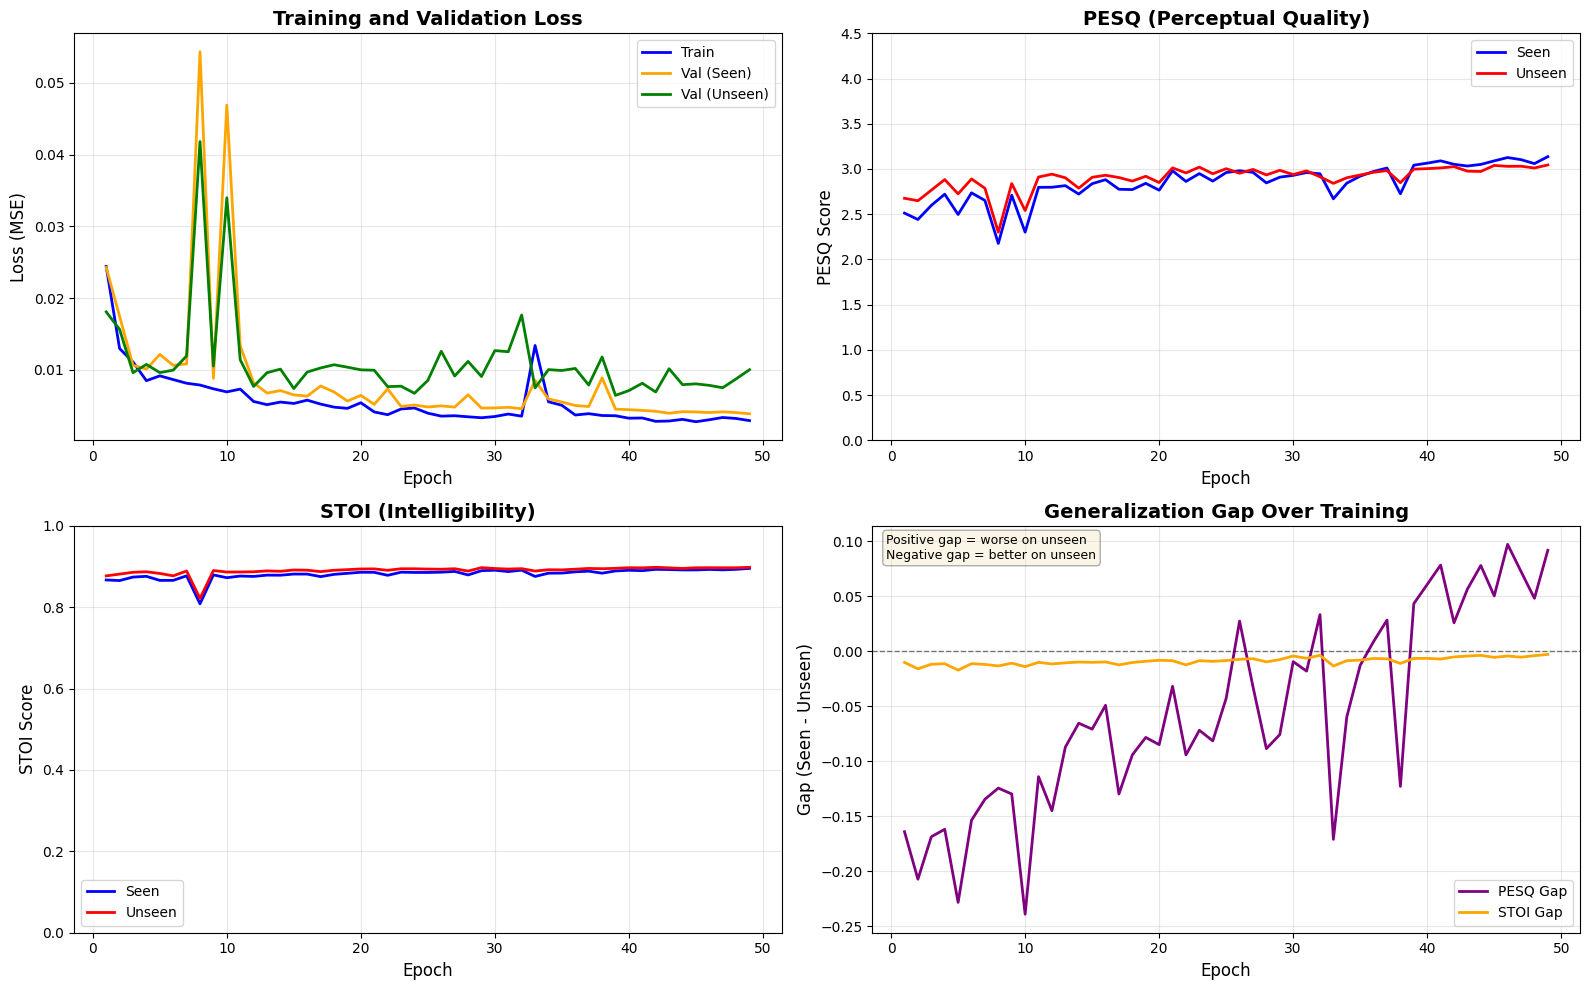

✓ Saved training curves to /home/paul/Desktop/projects/clarity-net/results/baseline_cnn/training_curves_with_metrics.png

Training Summary

Best epoch: 49
  Loss (seen):   0.003862
  Loss (unseen): 0.010006
  PESQ (seen):   3.136
  PESQ (unseen): 3.044
  STOI (seen):   0.895
  STOI (unseen): 0.898

Final epoch: 49
  Loss (seen):   0.003862
  Loss (unseen): 0.010006
  PESQ (seen):   3.136
  PESQ (unseen): 3.044
  STOI (seen):   0.895
  STOI (unseen): 0.898

Generalization Gaps (at best epoch):
  PESQ: +0.092
  STOI: -0.003

Generalization Gaps (at final epoch):
  PESQ: +0.092
  STOI: -0.003


In [52]:
from src.evaluation.visualize import plot_loss_curves

plot_loss_curves(history, RESULTS_DIR)

## Run Evaluation

In [34]:
# Load model and history for evaluation
from src.models.model_utils import load_checkpoint
checkpoint_path = CHECKPOINT_DIR / "best_model.pth"

model2 = UNetCNN(in_channels=1, base_channels=32).to(DEVICE)  # Create a new model instance
model2, history, epoch = load_checkpoint(checkpoint_path, model2, optimizer=None, scheduler=None)
print(f"Loaded model and history from {checkpoint_path} (epoch {epoch})")

Loaded model and history from /home/paul/Desktop/projects/clarity-net/checkpoints/baseline_cnn/best_model.pth (epoch 49)


In [39]:
import importlib
import src.evaluation.metrics as metrics_module
import src.evaluation.evaluate as eval_module

importlib.reload(metrics_module)
importlib.reload(eval_module)

evaluate_model = eval_module.evaluate_model

✓ Evaluation function defined


In [40]:
del evaluate_model  # Ensure we're using the latest version
from src.evaluation.evaluate import evaluate_model

results_seen, results_unseen = evaluate_model(model, test_seen_loader, test_unseen_loader, RESULTS_DIR, device=DEVICE)

Evaluating Model

Evaluating on SEEN noise types...


Test (Seen): 100%|██████████| 6/6 [00:04<00:00,  1.31it/s]



Evaluating on UNSEEN noise types...


Test (Unseen): 100%|██████████| 6/6 [00:04<00:00,  1.33it/s]


Results Summary

SEEN Noise Types:
  MSE:  0.003408
  PESQ: 2.887 ± 0.837
  STOI: 0.837 ± 0.293

UNSEEN Noise Types:
  MSE:  0.007454
  PESQ: 3.099 ± 0.914
  STOI: 0.836 ± 0.297

Generalization Gap:
  PESQ: -0.212
  STOI: 0.001

✓ Results saved to /home/paul/Desktop/projects/clarity-net/results/baseline_cnn/evaluation_results.json


## Visualize Audio Samples

Sample 1 - SNR: 4.6 dB
  PESQ: 2.720
  STOI: 0.922



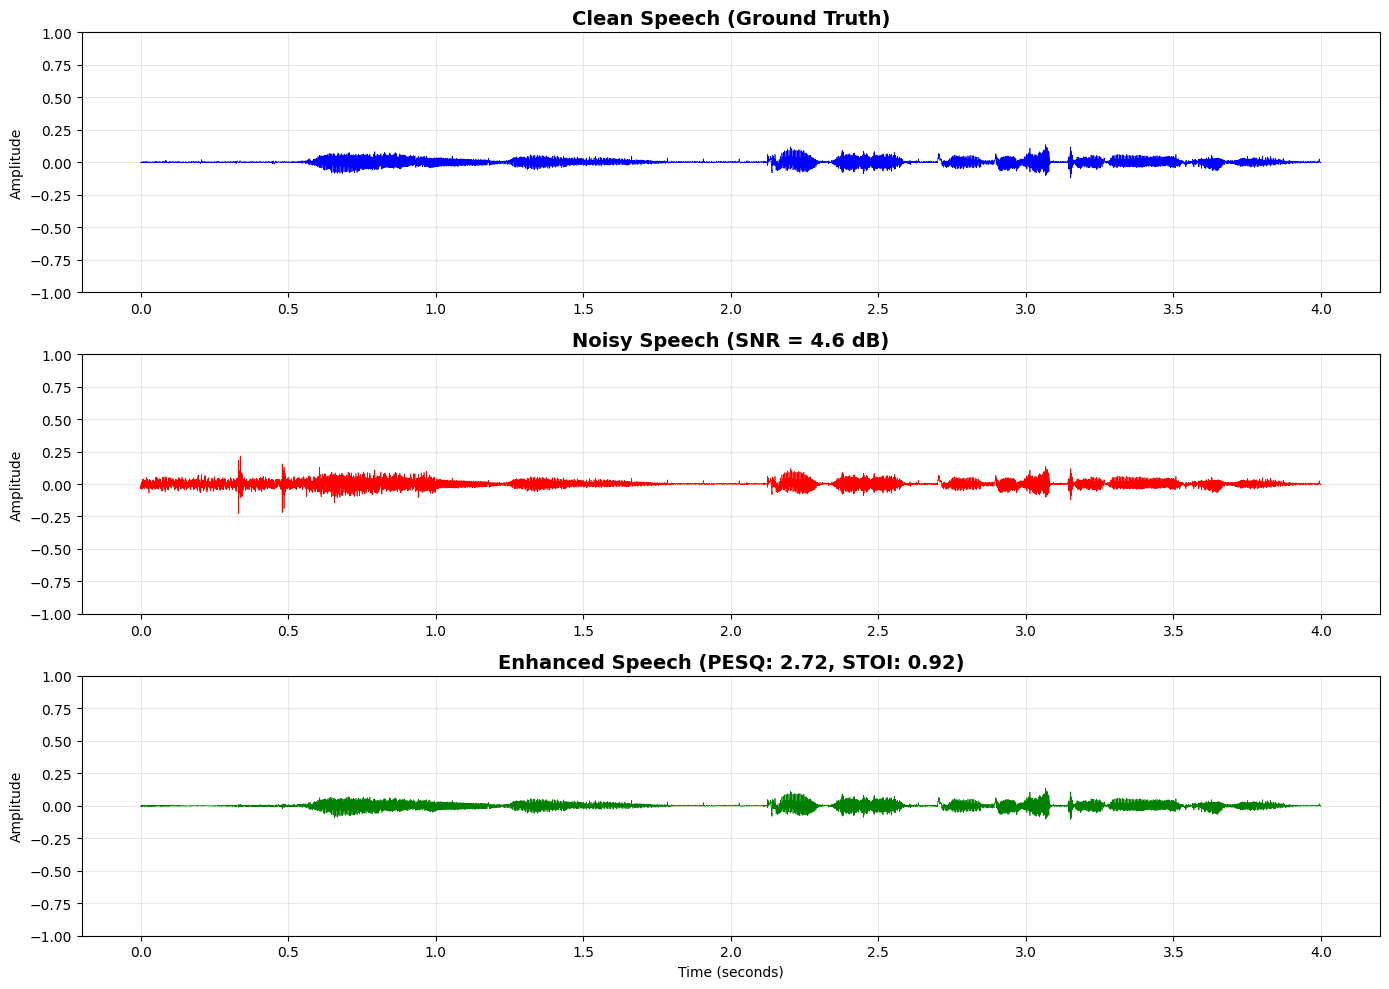

Waveform saved to /home/paul/Desktop/projects/clarity-net/results/baseline_cnn/waveform_comparison_sample_0.png


In [45]:
from src.evaluation.visualize import visualize_audio_samples

visualize_audio_samples(results_seen, RESULTS_DIR)

## Overlay Plots

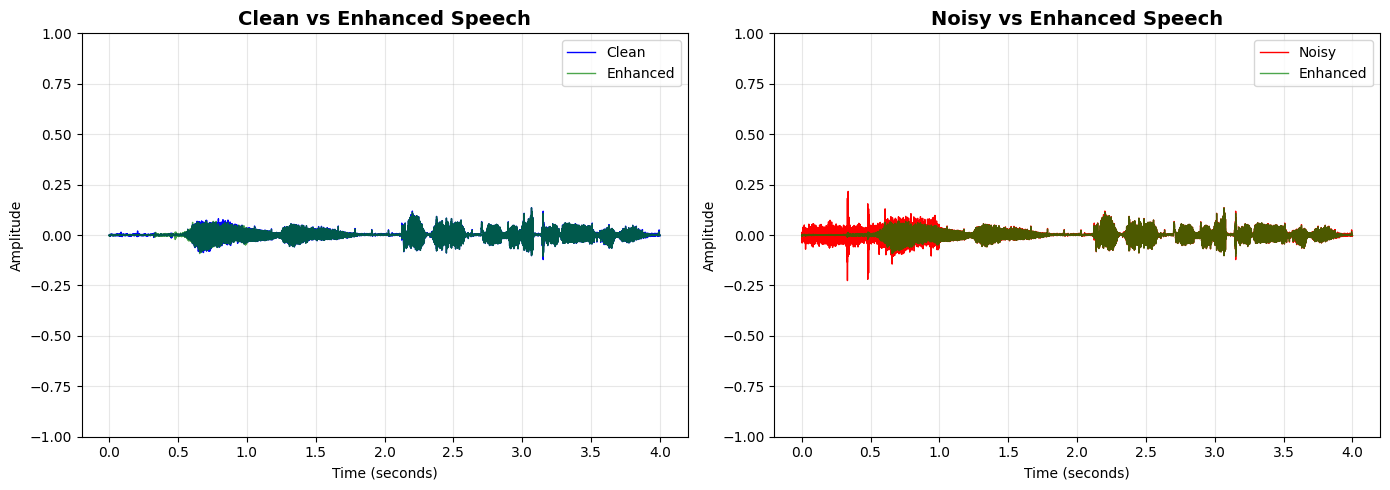

Overlay plots saved to /home/paul/Desktop/projects/clarity-net/results/baseline_cnn/overlay_comparison.png


In [46]:
from src.evaluation.visualize import visualize_audio_overlay

visualize_audio_overlay(results_seen, RESULTS_DIR)

## Audio Playback

In [47]:
from src.evaluation.visualize import playback_audio

playback_audio(results_seen)

Audio Data Inspection:
Sample rate: 16000 Hz
Clean audio shape: (64000,)
Clean audio dtype: float32
Clean audio range: [-0.121796, 0.135529]
Clean audio RMS: 0.016336
Clean audio duration: 4.00 seconds

Noisy audio shape: (64000,)
Noisy audio range: [-0.225860, 0.216256]
Noisy audio RMS: 0.019117

Enhanced audio shape: (64000,)
Enhanced audio range: [-0.106109, 0.134498]
Enhanced audio RMS: 0.016074

Clean Speech:



Noisy Speech (SNR = 4.6 dB):



Enhanced Speech (PESQ = 2.72, STOI = 0.92):


## Plot Metric Distributions

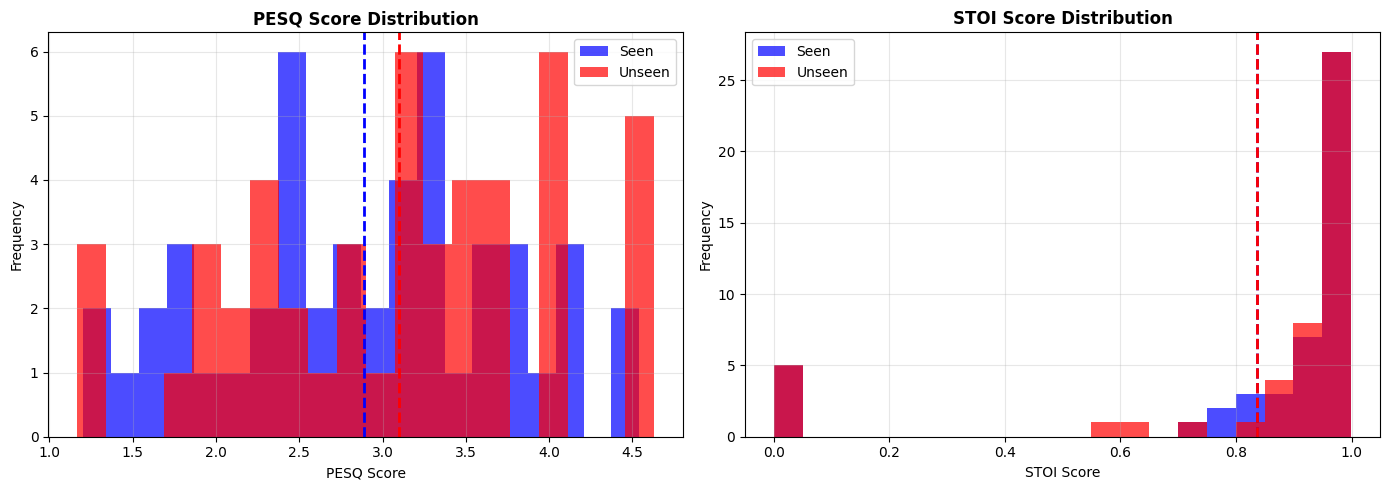

Metric distributions saved to /home/paul/Desktop/projects/clarity-net/results/baseline_cnn/metric_distributions.png


In [49]:
from src.evaluation.visualize import plot_metric_distributions

plot_metric_distributions(results_seen, results_unseen, RESULTS_DIR)

## Summary

### What We've Accomplished:

1. ✅ **Loaded data** from notebook 02 setup
2. ✅ **Created U-Net CNN baseline** with ~1.8M parameters
3. ✅ **Trained with proper validation** on seen and unseen noise
4. ✅ **Tracked generalization gap** throughout training
5. ✅ **Saved checkpoints** and training history

### Key Observations:

- **Training loss** should decrease steadily
- **Val (seen) loss** should track training loss (with gap = overfitting)
- **Val (unseen) loss** will be higher (this is the generalization gap)
- **Generalization gap** = your core research metric

### Next Steps:

1. Implement PESQ/STOI metrics for better evaluation
2. Train SOTA models (DeepFilterNet, DCCRN)
3. Implement ablations (augmentation, curriculum learning)
4. Compare all models on final test sets

### Files Created:

- `checkpoints/baseline_cnn/best_model.pth` — Best model checkpoint
- `checkpoints/baseline_cnn/training_history.json` — Loss curves data
- `checkpoints/baseline_cnn/training_curves.png` — Visualization